# Modelisation du jeu de données nettoyé

Ce notebook présente une exploration PCA en 3D, un découpage train/test/validation, un appel à une fonction de prétraitement externe, et un entraînement en boucle de plusieurs modèles. *Ce workflow doit avoir le jeux de données nettoyé en entrée*

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import re

# add root path, to import all modules
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
from src.accidents.data import load_collisions
from src.accidents.models.clustering import plot_3d, compute_methods

from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap
from sklearn.model_selection import train_test_split
import plotly.express as px

seed = 3795

DATA_PATH = Path('../data/clean/collisions_clean.csv')
df = load_collisions(DATA_PATH)

Charge : 217,956 lignes x 52 colonnes  (collisions_clean.csv)


### Choisir la colonne *target*

In [2]:
target = 'GRAVITE_3'
# target = 'GRAVITE'

classes = df[target].unique()
c = len(classes)
print(classes)

<StringArray>
['Materiel', 'Leger', 'Grave']
Length: 3, dtype: str


### Loader les colonnes et split

In [3]:
gravite_column = next((c for c in df.columns if c.upper() == target), None)
if gravite_column is None:
    raise ValueError(f'Impossible de trouver une colonne {target} dans le jeu de données nettoyé.')

# X = toutes les colonnes sauf la cible
# Les colonnes de fuite (NB_MORTS, NB_BLESSES_*, etc.) seront retirees par preprocess_data()
feature_columns = [c for c in df.columns if c.upper() not in {'GRAVITE', 'GRAVITE_3'}]
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
if not feature_columns:
    raise ValueError(f'Aucune colonne numérique disponible pour la PCA après exclusion de {target}.')

X = df[feature_columns].copy()
y = df[gravite_column].copy()

print(f'Features disponibles : {len(feature_columns)}')
print(f'Distribution de la cible :')
print(y.value_counts())

Features disponibles : 50
Distribution de la cible :
GRAVITE_3
Materiel    169998
Leger        45910
Grave         2048
Name: count, dtype: int64


## Découpage train / validation / test

Nous préparons le jeu de données pour l'entraînement en séparant d'abord un test set, puis en divisant le reste entre entraînement et validation.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=seed
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=seed
)

print('Tailles :')
print('  X_train', X_train.shape)
print('  X_val', X_val.shape)
print('  X_test', X_test.shape)

Tailles :
  X_train (174364, 50)
  X_val (21796, 50)
  X_test (21796, 50)


### Check des petites classes

In [5]:
print("Proportions de chaque classe des ensembles:")
print('  Y_train_proc', y_train.value_counts())
print('  Y_val_proc', y_val.value_counts())
print('  Y_test_proc', y_test.value_counts())

Proportions de chaque classe des ensembles:
  Y_train_proc GRAVITE_3
Materiel    135998
Leger        36728
Grave         1638
Name: count, dtype: int64
  Y_val_proc GRAVITE_3
Materiel    17000
Leger        4591
Grave         205
Name: count, dtype: int64
  Y_test_proc GRAVITE_3
Materiel    17000
Leger        4591
Grave         205
Name: count, dtype: int64


## Appel au prétraitement externe

Ce notebook invoque la fonction `preprocess_data` située dans `src.accidents.preprocessing`. Cette fonction applique :
1. Le retrait des colonnes qui fuitent la cible (`NB_MORTS`, `NB_BLESSES_*`, etc.)
2. Un target encoding sur les catégorielles à forte cardinalité (`REG_ADM`, `MRC`)
3. Un one-hot encoding sur les autres catégorielles
4. Une standardisation (z-score) de toutes les colonnes

Toutes les statistiques sont calculées uniquement sur `X_train` pour éviter toute fuite.

In [6]:
from src.accidents.preprocessing.preprocessing import preprocess_data

X_train_proc, X_val_proc, X_test_proc = preprocess_data(X_train, y_train, X_val, X_test)

print('Prétraitement terminé. Formes finales :')
print('  X_train_proc', X_train_proc.shape)
print('  X_val_proc', X_val_proc.shape)
print('  X_test_proc', X_test_proc.shape)

--- Imputation train ---
VITESSE_AUTOR : 64813 NaN imputés
HEURE : 13743 NaN imputés
--- Imputation val ---
VITESSE_AUTOR : 7939 NaN imputés
HEURE : 1738 NaN imputés
--- Imputation test ---
VITESSE_AUTOR : 7972 NaN imputés
HEURE : 1693 NaN imputés
Colonnes de fuite retirees. Shape apres : (174364, 37)
Encodage cyclique applique a HEURE (periode 24)
Encodage cyclique applique a MOIS (periode 12)
Encodage cyclique applique a JR_SEMN_ACCDN (periode 7)
Encodage cyclique applique a HEURE (periode 24)
Encodage cyclique applique a MOIS (periode 12)
Encodage cyclique applique a JR_SEMN_ACCDN (periode 7)
Encodage cyclique applique a HEURE (periode 24)
Encodage cyclique applique a MOIS (periode 12)
Encodage cyclique applique a JR_SEMN_ACCDN (periode 7)
Target encoding applique a : ['REG_ADM', 'MRC']
One-hot applique a : ['SAISON', 'CD_GENRE_ACCDN', 'CD_ETAT_SURFC', 'CD_ECLRM', 'CD_ENVRN_ACCDN', 'CD_CATEG_ROUTE', 'CD_ASPCT_ROUTE', 'CD_LOCLN_ACCDN', 'CD_CONFG_ROUTE', 'CD_COND_METEO', 'LOC_COTE_QD'

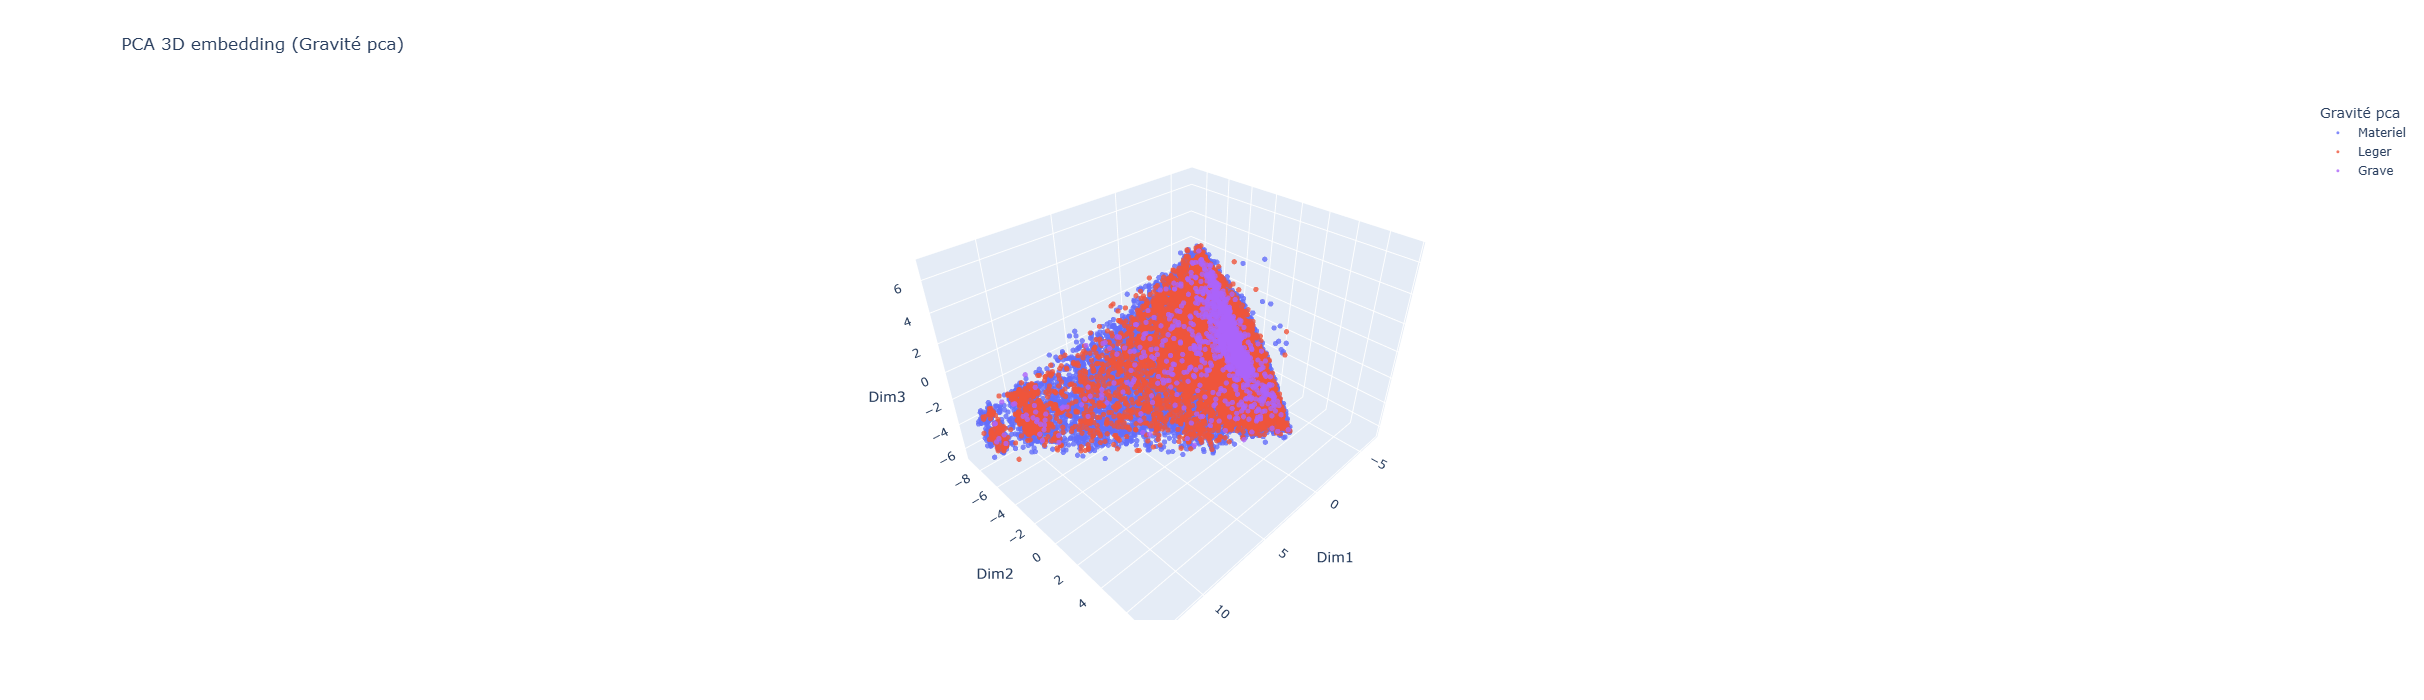

In [7]:
embeds_clean = compute_methods(X_train_proc, methods=["pca"])

for method, embed in embeds_clean.items():
    fig = plot_3d(embed, 
                  labels=y_train,   # attention : y_train maintenant, pas y
                  method_name=f"{method}", 
                  label_name=f"Gravité {method}")
    fig.show()

---

# Entrainement de modèles

In [8]:
from sklearn.cluster import AgglomerativeClustering, Birch, KMeans, DBSCAN
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    accuracy_score, 
    classification_report, 
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

### Boucle d'entraînement de méthodes de regroupement
#### Métriques:
- Adjusted Rand Index (ARI): Mesure la similarité entre les vrais regroupements et les regroupements prédits    `(best:1, worst:-0.5)`
- Adjusted Mutual Information (AMI): Similaire à ARI, avec l'information mutuelles des regroupements    `(best:1, worst:0)`
- Homogeneity: La pureté des regroupements comparativement aux vraies classes   `(best:1, worst:0)`
- Silhouette Score: Measure de la séparation entre les regroupements (unsupervised)    `(best:1, worst:-1)`

In [9]:

models = {
    #'KMeans': KMeans(n_clusters=c, random_state=seed),
    # 'AgglomerativeClustering': AgglomerativeClustering(n_clusters=c),
    # 'Birch': Birch(n_clusters=c),
    'DBSCAN': DBSCAN(eps=4, min_samples=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train_proc)
    if hasattr(model, 'predict'):
        labels_val = model.predict(X_val_proc)
    else:
        labels_val = model.fit_predict(X_val_proc)

    ari = adjusted_rand_score(y_val, labels_val)
    ami = adjusted_mutual_info_score(y_val, labels_val)
    hom = homogeneity_score(y_val, labels_val)
    v = v_measure_score(y_val, labels_val)
    sil = silhouette_score(X_val_proc, labels_val)

    results[name] = {
        'ARI': ari,
        'AMI': ami,
        'Homogeneity': hom,
        'Silhouette': sil,
    }

    print(f'{name}:')
    print(f'  ARI: {ari:.4f}')
    print(f'  AMI: {ami:.4f}')
    print(f'  Homogeneity: {hom:.4f}')
    print(f'  Silhouette: {sil:.4f}')

print('Résumé des performances :')
for name, metrics in results.items():
    print(
        f'{name}: ARI={metrics["ARI"]:.4f}, AMI={metrics["AMI"]:.4f}, Silhouette={metrics["Silhouette"]:.4f}'
    )

C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


DBSCAN:
  ARI: 0.0232
  AMI: 0.0350
  Homogeneity: 0.0612
  Silhouette: -0.2686
Résumé des performances :
DBSCAN: ARI=0.0232, AMI=0.0350, Silhouette=-0.2686


### Boucle d'entraînement de classifieurs

Nous définissons plusieurs classifieurs scikit-learn, puis comparons leurs performances sur le jeu de validation.

Dummy (majorite): validation accuracy = 0.7800
Classification report:


C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

              precision    recall  f1-score   support

       Grave       0.00      0.00      0.00       205
       Leger       0.00      0.00      0.00      4591
    Materiel       0.78      1.00      0.88     17000

    accuracy                           0.78     21796
   macro avg       0.26      0.33      0.29     21796
weighted avg       0.61      0.78      0.68     21796



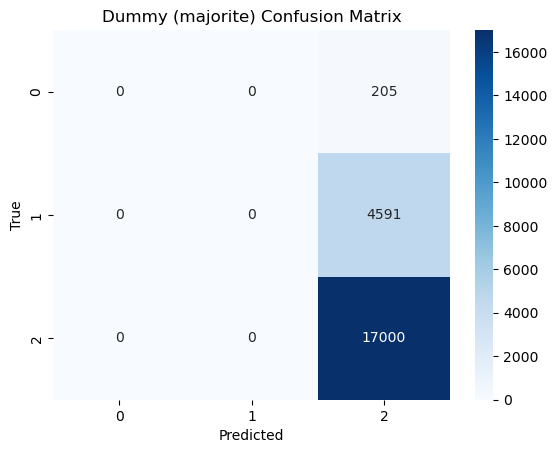

Dummy (stratifie): validation accuracy = 0.6539
Classification report:
              precision    recall  f1-score   support

       Grave       0.01      0.01      0.01       205
       Leger       0.21      0.21      0.21      4591
    Materiel       0.78      0.78      0.78     17000

    accuracy                           0.65     21796
   macro avg       0.33      0.33      0.33     21796
weighted avg       0.65      0.65      0.65     21796



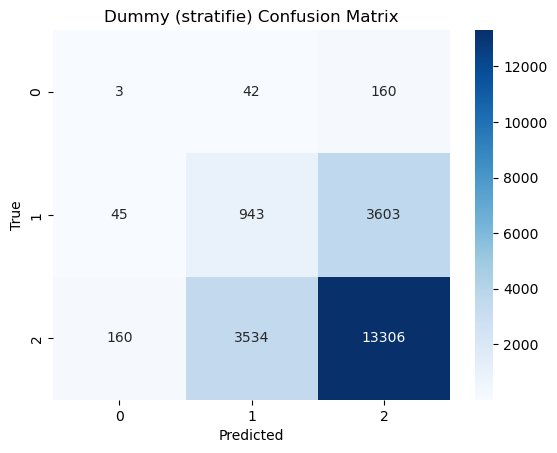

GaussianNB: validation accuracy = 0.0688
Classification report:
              precision    recall  f1-score   support

       Grave       0.01      0.99      0.02       205
       Leger       0.37      0.01      0.02      4591
    Materiel       0.94      0.07      0.14     17000

    accuracy                           0.07     21796
   macro avg       0.44      0.36      0.06     21796
weighted avg       0.81      0.07      0.11     21796



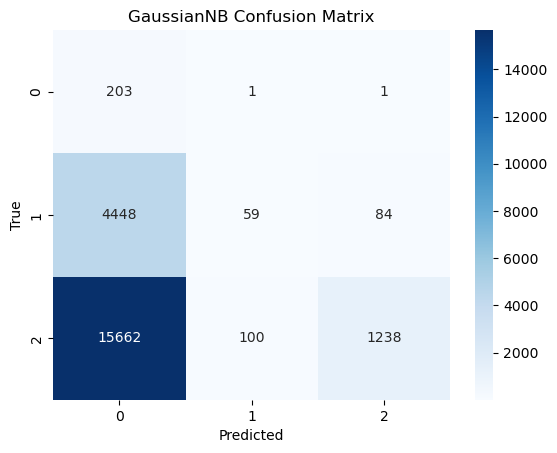

SVM: validation accuracy = 0.8407
Classification report:


C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pierre Emery\miniconda3\envs\accidents-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

              precision    recall  f1-score   support

       Grave       0.00      0.00      0.00       205
       Leger       0.75      0.39      0.51      4591
    Materiel       0.85      0.97      0.91     17000

    accuracy                           0.84     21796
   macro avg       0.53      0.45      0.47     21796
weighted avg       0.82      0.84      0.82     21796



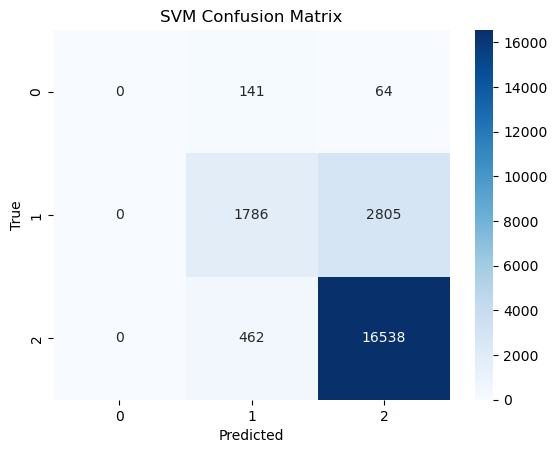

Decision Tree: validation accuracy = 0.8410
Classification report:
              precision    recall  f1-score   support

       Grave       0.21      0.02      0.04       205
       Leger       0.76      0.38      0.51      4591
    Materiel       0.85      0.98      0.91     17000

    accuracy                           0.84     21796
   macro avg       0.61      0.46      0.48     21796
weighted avg       0.83      0.84      0.82     21796



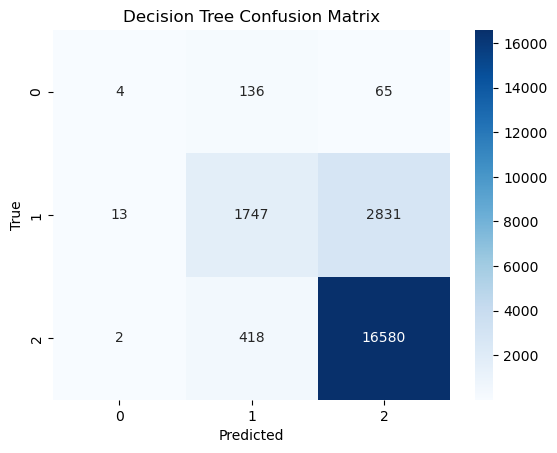

Random Forest: validation accuracy = 0.8420
Classification report:
              precision    recall  f1-score   support

       Grave       0.00      0.00      0.00       205
       Leger       0.74      0.41      0.53      4591
    Materiel       0.86      0.97      0.91     17000

    accuracy                           0.84     21796
   macro avg       0.53      0.46      0.48     21796
weighted avg       0.82      0.84      0.82     21796



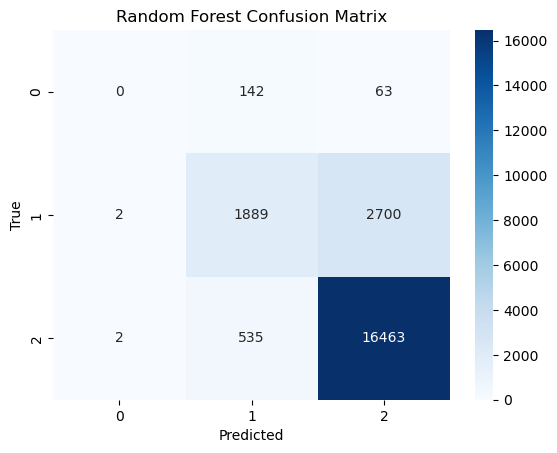

Résumé des performances :
  Dummy (majorite): 0.7800
  Dummy (stratifie): 0.6539
  GaussianNB: 0.0688
  SVM: 0.8407
  Decision Tree: 0.8410
  Random Forest: 0.8420


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


models = {
    'Dummy (majorite)': DummyClassifier(strategy='most_frequent', random_state=seed),
    'Dummy (stratifie)': DummyClassifier(strategy='stratified', random_state=seed),
    'GaussianNB': GaussianNB(),
    'SVM': LinearSVC(random_state=seed),
    'Decision Tree': DecisionTreeClassifier(random_state=seed, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=seed)
}

results = {}
trained_models = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    y_val_pred = model.predict(X_val_proc)
    score = accuracy_score(y_val, y_val_pred)
    results[name] = score
    trained_models[name] = model
    print(f'{name}: validation accuracy = {score:.4f}')
    print("Classification report:")
    print(classification_report(y_val, y_val_pred))
    
    # plot confusion matrix
    sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

print('Résumé des performances :')
for name, score in results.items():
    print(f'  {name}: {score:.4f}')

# Déséquilibre de classes
La classe "Grave" ne représente que <1% des données. Du coup les modèles ont tendance à l'ignorer pour maximiser l'accuracy globale. On compare alors trois stratégies pour améliorer la détection des cas graves, toutes appliquées au Random Forest :

1. **Aucune** : baseline, on laisse faire le déséquilibre
2. **`class_weight='balanced'`** : on pénalise plus fortement les erreurs sur les classes rares (sans toucher aux données)
3. **SMOTE** : on génère des exemples synthétiques de la classe minoritaire par interpolation


In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, balanced_accuracy_score

# SMOTE une seule fois
smote = SMOTE(random_state=seed)
X_tr_smote, y_tr_smote = smote.fit_resample(X_train_proc, y_train)

strategies_models = {
    'Aucune': {
        'GaussianNB': GaussianNB(),
        'SVM': LinearSVC(random_state=seed, max_iter=2000),
        'Random Forest': RandomForestClassifier(random_state=seed, n_estimators=200, n_jobs=-1),
    },
    'Balanced': {
        'GaussianNB': GaussianNB(priors=[1/3, 1/3, 1/3]),
        'SVM': LinearSVC(random_state=seed, max_iter=2000, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(
            random_state=seed,
            n_estimators=200,
            n_jobs=-1,
            class_weight='balanced'
        ),
    },
    'SMOTE': {
        'GaussianNB': GaussianNB(),
        'SVM': LinearSVC(random_state=seed, max_iter=2000),
        'Random Forest': RandomForestClassifier(random_state=seed, n_estimators=200, n_jobs=-1),
    },
}

comparison = []
trained = {}

for strategie, models_dict in strategies_models.items():

    X_tr = X_tr_smote if strategie == 'SMOTE' else X_train_proc
    y_tr = y_tr_smote if strategie == 'SMOTE' else y_train

    trained[strategie] = {}

    for model_name, model in models_dict.items():

        model.fit(X_tr, y_tr)
        trained[strategie][model_name] = model

        y_pred = model.predict(X_val_proc)

        f1_per_class = f1_score(
            y_val,
            y_pred,
            labels=['Grave', 'Leger', 'Materiel'],
            average=None,
            zero_division=0
        )

        comparison.append({
            'Strategie': strategie,
            'Modele': model_name,
            'Accuracy': accuracy_score(y_val, y_pred),
            'Balanced Acc': balanced_accuracy_score(y_val, y_pred),
            'F1 macro': f1_score(y_val, y_pred, average='macro', zero_division=0),
            'F1 Grave': f1_per_class[0],
        })

comparison_df = pd.DataFrame(comparison)

print("=== Comparaison strategies × modeles ===")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

pivot = comparison_df.pivot(index='Modele', columns='Strategie', values='F1 macro')

print("\n=== Pivot : F1 macro par modele × strategie ===")
print(pivot.to_string(float_format=lambda x: f'{x:.4f}'))

=== Comparaison strategies × modeles ===
Strategie        Modele  Accuracy  Balanced Acc  F1 macro  F1 Grave
   Aucune    GaussianNB    0.0688        0.3586    0.0599    0.0198
   Aucune           SVM    0.8407        0.4539    0.4734    0.0000
   Aucune Random Forest    0.8422        0.4597    0.4787    0.0000
 Balanced    GaussianNB    0.0678        0.3584    0.0595    0.0198
 Balanced           SVM    0.8240        0.5170    0.5217    0.1258
 Balanced Random Forest    0.8392        0.4534    0.4743    0.0096
    SMOTE    GaussianNB    0.1409        0.3784    0.1128    0.0207
    SMOTE           SVM    0.6886        0.6304    0.4459    0.1033
    SMOTE Random Forest    0.8340        0.4665    0.4844    0.0186

=== Pivot : F1 macro par modele × strategie ===
Strategie      Aucune  Balanced  SMOTE
Modele                                
GaussianNB     0.0599    0.0595 0.1128
Random Forest  0.4787    0.4743 0.4844
SVM            0.4734    0.5217 0.4459


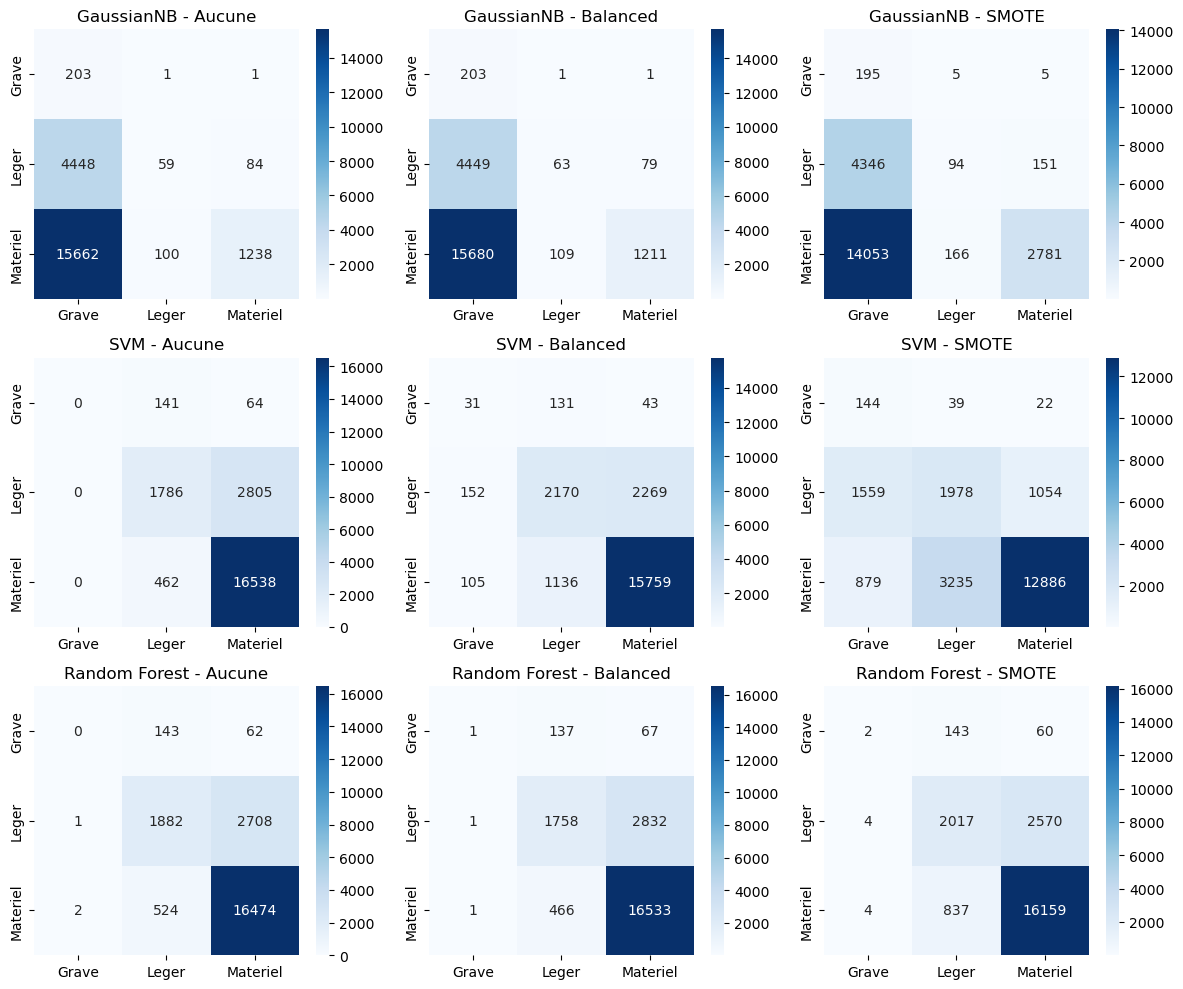

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

labels = ['Grave', 'Leger', 'Materiel']
model_names = ['GaussianNB', 'SVM', 'Random Forest']

for i, model_name in enumerate(model_names):
    for j, strategie in enumerate(strategies_models.keys()):

        ax = axes[i, j]
        model = trained[strategie][model_name]

        y_pred = model.predict(X_val_proc)

        cm = confusion_matrix(y_val, y_pred, labels=labels)

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            xticklabels=labels,
            yticklabels=labels
        )

        ax.set_title(f"{model_name} - {strategie}")

plt.tight_layout()
plt.show()

# Finalement, testons les modèles retenus sur l'ensemble de test qui a été écarté préalablement. 
Les modèles qu'on choisi de tester sont les deux suivants :
1. Random Forest sans stratégie d'augmentation de la classe minoritaire puisque c'est le modèle aevec la meilleure accuracy
2. SVM Balanced puisque c'est le meilleur compromis détection/accuracy (F1 Grave = 0.126)

In [13]:
final_models = {
    'Random Forest': trained['Aucune']['Random Forest'],
    'SVM (Balanced)': trained['Balanced']['SVM'],
}

print("=" * 60)
print("ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST ")
print("=" * 60)
print()

test_results = []
for name, model in final_models.items():
    y_test_pred = model.predict(X_test_proc)
    
    f1_grave = f1_score(
        y_test, y_test_pred, 
        labels=['Grave'], average=None, zero_division=0
    )[0]
    
    test_results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Balanced Acc.': balanced_accuracy_score(y_test, y_test_pred),
        'F1 macro': f1_score(y_test, y_test_pred, average='macro', zero_division=0),
        'F1 Grave': f1_grave,
    })
    
    print(f'--- {name} ---')
    print(classification_report(y_test, y_test_pred, zero_division=0))
    print()

# Tableau récapitulatif
test_df = pd.DataFrame(test_results)
print("=== Tableau récapitulatif (test set) ===")
print(test_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST 

--- Random Forest ---
              precision    recall  f1-score   support

       Grave       0.00      0.00      0.00       205
       Leger       0.73      0.42      0.53      4591
    Materiel       0.86      0.97      0.91     17000

    accuracy                           0.84     21796
   macro avg       0.53      0.46      0.48     21796
weighted avg       0.82      0.84      0.82     21796


--- SVM (Balanced) ---
              precision    recall  f1-score   support

       Grave       0.09      0.15      0.12       205
       Leger       0.63      0.48      0.55      4591
    Materiel       0.87      0.92      0.90     17000

    accuracy                           0.82     21796
   macro avg       0.53      0.52      0.52     21796
weighted avg       0.82      0.82      0.82     21796


=== Tableau récapitulatif (test set) ===
        Modèle  Accuracy  Balanced Acc.  F1 macro  F1 Grave
 Random Forest    0.8415         0.4615    0.48